In [14]:
import pandas as pd
import numpy as np
from tqdm import tqdm

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import cv2

# Load CSVs
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(train_df.head())
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

# Load a sample image
sample_id = train_df.iloc[0]["Id"]
sample_label = train_df.iloc[0]["Category"]
img_path = Path(f"train/train/{sample_label}/{sample_id}.png")

      Id  Category
0   7168         6
1   9876         3
2  78117         6
3   9626         1
4  29492         3
Train size: 17000, Test size: 3000


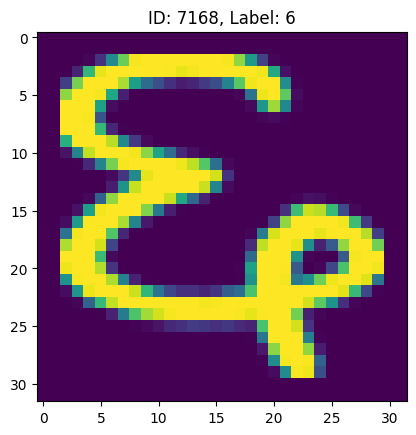

In [15]:
# view original image
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"ID: {sample_id}, Label: {sample_label}")
plt.show()

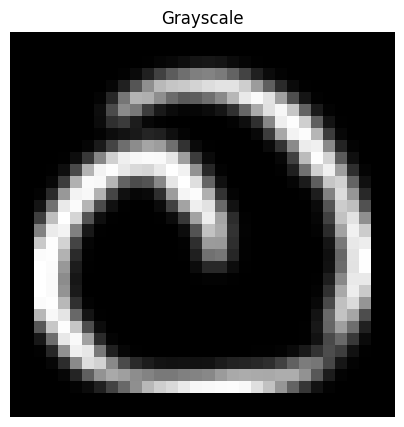

In [16]:
# convert to grayscale
# function from lab 3
def show_images(images, titles, cmap=None):
    n = len(images)
    plt.figure(figsize=(5*n, 5))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

# Pick one image from class 0
img_path = "train/train/0/103265.png"
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

show_images([gray], ["Grayscale"])

In [17]:
# train images to grayscale
# import pandas as pd
# import numpy as np

# train_df = pd.read_csv("train.csv")

# images = []
# labels = []

# for _, row in train_df.iterrows():
#     img_id = row["Id"]
#     label = row["Category"]
#     path = f"train/train/{label}/{img_id}.png"
    
#     img = cv2.imread(path)
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     images.append(gray)
#     labels.append(label)

# images = np.array(images)
# labels = np.array(labels)

# print(f"Loaded {len(images)} images, shape: {images.shape}")

In [18]:
# # save grayscale images locally
# from pathlib import Path

# output_dir = Path("train_gray")
# output_dir.mkdir(exist_ok=True)

# for _, row in train_df.iterrows():
#     img_id = row["Id"]
#     label = row["Category"]
#     path = f"train/train/{label}/{img_id}.png"
    
#     img = cv2.imread(path)
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     cv2.imwrite(str(output_dir / f"{img_id}.png"), gray)

# print("Done saving grayscale images")

In [19]:
# read in grayscale images
train_df = pd.read_csv("train.csv")

images = np.array([
    cv2.imread(f"train_gray/{row['Id']}.png", cv2.IMREAD_GRAYSCALE)
    for _, row in tqdm(train_df.iterrows(), total=len(train_df))
])
labels = train_df["Category"].values

print(f"Loaded {len(images)} images, shape: {images.shape}")

100%|██████████████████████████████████████████████████████████████████████████| 17000/17000 [00:03<00:00, 4566.91it/s]


Loaded 17000 images, shape: (17000, 32, 32)


In [20]:
# train val split:
from sklearn.model_selection import train_test_split
# Flatten images: (N, 32, 32) -> (N, 1024)
X = images.reshape(len(images), -1) / 255.0  # normalize to 0-1
y = labels

# reshuffle and split into train and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=75, stratify=y)

In [21]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Train
svm = SVC(kernel="rbf", C=10, gamma=0.01)
svm.fit(X_train, y_train)

# Evaluate
y_pred_svm = svm.predict(X_val)
print(f"SVM val_accuracy: {accuracy_score(y_val, y_pred_svm):.4f}")


SVM val_accuracy: 0.9925


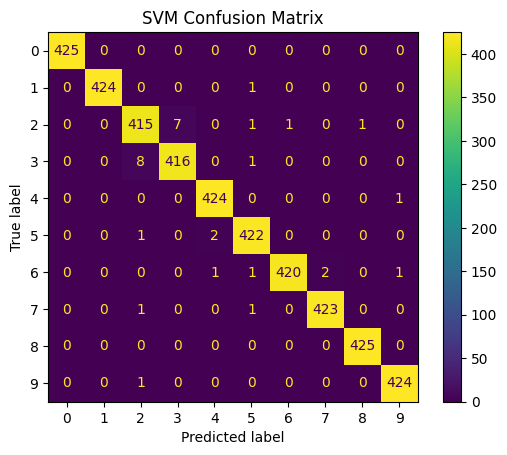

Most confused: true=3, predicted as=2 (8 errors)
Found 8 misclassified 3s predicted as 2


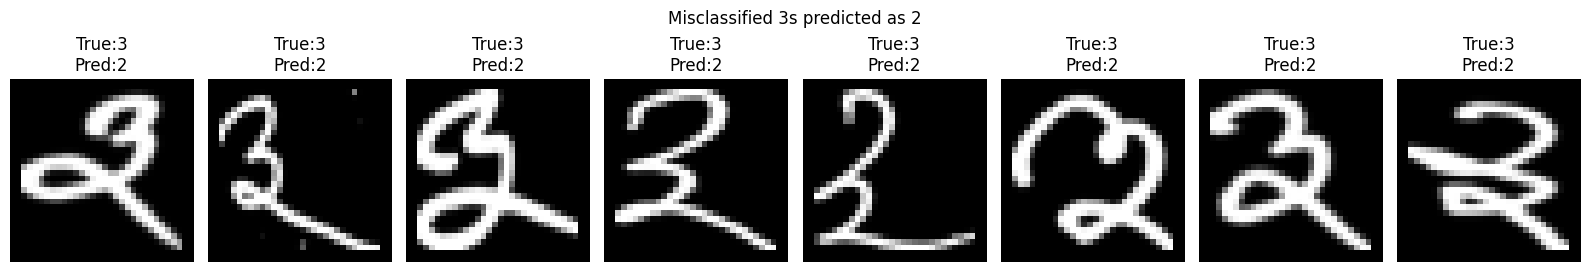

In [22]:
# confusion matrix
cm = confusion_matrix(y_val, y_pred_svm)
ConfusionMatrixDisplay(cm).plot()
plt.title("SVM Confusion Matrix")
plt.show()

# find the two most confused classes
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
most_confused = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
true_class, pred_class = most_confused
print(f"Most confused: true={true_class}, predicted as={pred_class} ({cm_no_diag[true_class, pred_class]} errors)")

# visualize misclassified images from that pair
mask = (y_val == true_class) & (y_pred_svm == pred_class)
misclassified_idx = np.where(mask)[0]
print(f"Found {len(misclassified_idx)} misclassified {true_class}s predicted as {pred_class}")

n = min(10, len(misclassified_idx))
plt.figure(figsize=(2*n, 3))
for i, idx in enumerate(misclassified_idx[:n]):
    img = X_val[idx].reshape(32, 32)
    plt.subplot(1, n, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True:{y_val[idx]}\nPred:{y_pred_svm[idx]}")
    plt.axis('off')
plt.suptitle(f"Misclassified {true_class}s predicted as {pred_class}")
plt.tight_layout()
plt.show()

In [23]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {"C": [1, 10, 100], "gamma": [0.001, 0.01, "scale"]}
# grid = GridSearchCV(SVC(kernel="rbf"), param_grid, cv=3, verbose=2)
# grid.fit(X_train, y_train)
# print(f"Best params: {grid.best_params_}")
# print(f"Best accuracy: {grid.best_score_:.4f}")

In [28]:
# add augmented features
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Define augmentation
datagen = ImageDataGenerator(
    rotation_range=0.1,        # rotate up to 10 degrees
    width_shift_range=0.1,    # shift horizontally up to 10%
    height_shift_range=0.1,   # shift vertically up to 10%
    zoom_range=0.1,           # zoom in/out up to 10%
    shear_range=0.1           # slight shear
)

# Reshape back to images for augmentation
X_train_img = X_train.reshape(-1, 32, 32, 1)

# Retrain SVM with augmented data
X_aug = []
y_aug = []

for X_batch, y_batch in datagen.flow(X_train_img, y_train, batch_size=len(X_train)):
    X_aug.append(X_batch.reshape(-1, 1024))  # flatten back
    y_aug.append(y_batch)
    break  # one pass = same size as original

# Combine original + augmented
X_combined = np.vstack([X_train, X_aug[0]])
y_combined = np.concatenate([y_train, y_aug[0]])

print(f"Original: {len(X_train)} | Augmented: {len(X_combined)}")

# Retrain SVM
aug_svm = SVC(kernel="rbf", C=10, gamma=0.01)
aug_svm.fit(X_combined, y_combined)

y_pred_aug = aug_svm.predict(X_val)
print(f"Augmented SVM val_accuracy: {accuracy_score(y_val, y_pred_aug):.4f}")

Original: 12750 | Augmented: 25500
Augmented SVM val_accuracy: 0.9951


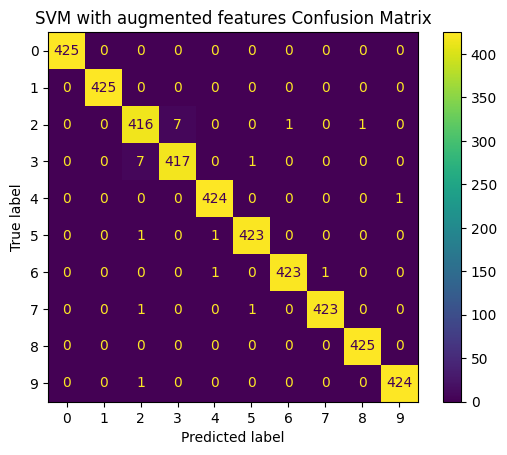

Most confused: true=2, predicted as=3 (7 errors)
Found 7 misclassified 2s predicted as 3


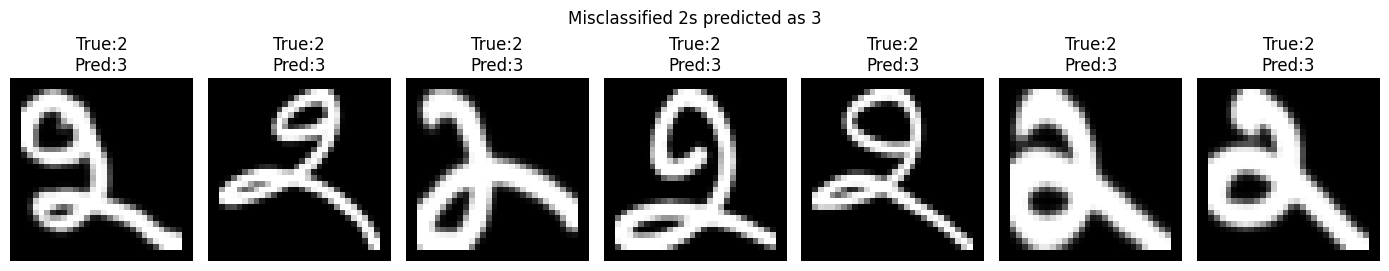

In [25]:
# confusion matrix
cm = confusion_matrix(y_val, y_pred_aug)
ConfusionMatrixDisplay(cm).plot()
plt.title("SVM with augmented features Confusion Matrix")
plt.show()

# find the two most confused classes
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
most_confused = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
true_class, pred_class = most_confused
print(f"Most confused: true={true_class}, predicted as={pred_class} ({cm_no_diag[true_class, pred_class]} errors)")

# visualize misclassified images from that pair
mask = (y_val == true_class) & (y_pred_aug == pred_class)
misclassified_idx = np.where(mask)[0]
print(f"Found {len(misclassified_idx)} misclassified {true_class}s predicted as {pred_class}")

n = min(10, len(misclassified_idx))
plt.figure(figsize=(2*n, 3))
for i, idx in enumerate(misclassified_idx[:n]):
    img = X_val[idx].reshape(32, 32)
    plt.subplot(1, n, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True:{y_val[idx]}\nPred:{y_pred_aug[idx]}")
    plt.axis('off')
plt.suptitle(f"Misclassified {true_class}s predicted as {pred_class}")
plt.tight_layout()
plt.show()

In [26]:
from skimage.feature import hog

def extract_hog(images):
    features = []
    for img in images:
        fd = hog(img.reshape(32, 32), orientations=9,
                 pixels_per_cell=(4, 4), cells_per_block=(2, 2))
        features.append(fd)
    return np.array(features)

X_train_hog = extract_hog(X_train)
X_val_hog = extract_hog(X_val)

hog_svm = SVC(kernel="rbf", C=10, gamma=0.01)
hog_svm.fit(X_train_hog, y_train)
print(f"HOG SVM: {accuracy_score(hog_svm.predict(X_val_hog), y_val):.4f}")

HOG SVM: 0.9939
